![](https://img.freepik.com/premium-vector/urban-suburban-neighborhood-night-with-real-estate-property-houses-with-lights-cartoon-landscape-with-suburban-cottages-moon-stars-dark-sky-vector-illustration-flat-style_165488-1556.jpg?w=2000)

<div style='font-size:200%;background-color:  #180A49; border-radius:5px'>
    <a id='nan'></a>
    <h1 style='color: white; font-weight: bold; font-family: Cascadia code;'> Contents </h1><a id="mainmenu"></a>

</div>

- [1.Importing necessary libraries](#import)
- [2.Loading datasets](#data) 
- [3.Miss information analysis](#missing)
- [4.Preprocessing](#preposs)
- [5.Modeling](#model) 
- [6.Submission](#Submisson)

- - -

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left> ||| 1.Importing necessary libraries</left></h2><a id="import"></a>
</div>
    
[Back to the contents](#mainmenu)

In [1]:
from IPython.display import HTML
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import mutual_info_regression

import numpy as np
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 2.Loading datasets</left></h2><a id="data"></a>
</div>

[Back to the contents](#mainmenu)

In [2]:
train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 3.Miss information analysis</left></h2><a id="missing"></a>
</div>
    
[Back to the contents](#mainmenu)

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's check datatypes of train.</left></h2><a id="missing"></a>
</div>

<AxesSubplot:>

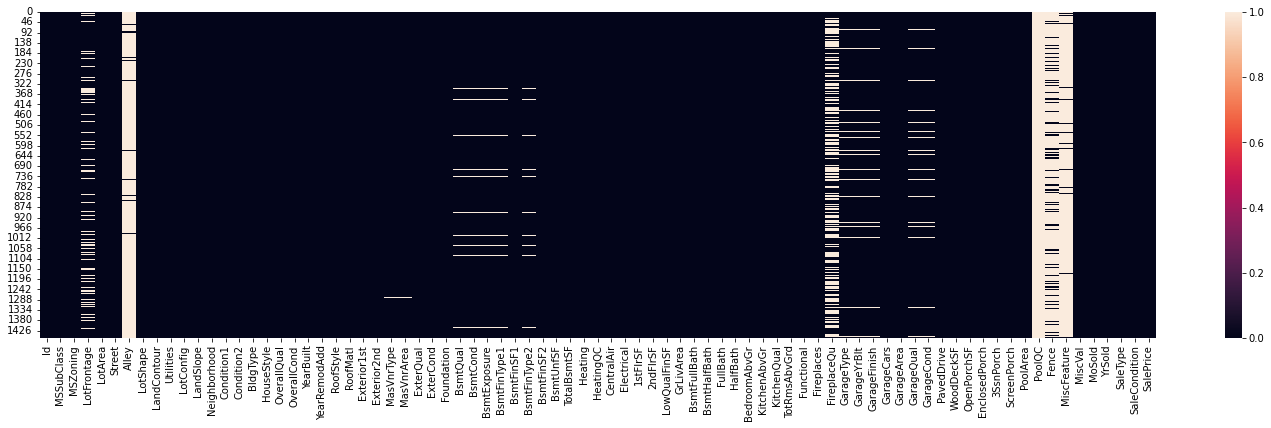

In [3]:
fig,ax = plt.subplots(figsize=(25,6))
sns.heatmap(train.isnull())

In [4]:
train.isnull().sum()[train.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
num_cols = [cname for cname in train.columns if train[cname].dtype in ['int64', 'float64'] and cname != "SalePrice"]
cat_cols = [cname for cname in train.columns if train[cname].dtype == "object"]

In [7]:
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [8]:
num_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [9]:
train[num_cols]=train[num_cols].fillna(0)
train[cat_cols]=train[cat_cols].fillna("none")
test[num_cols]=test[num_cols].fillna(0)
test[cat_cols]=test[cat_cols].fillna("none")

In [10]:
train.isnull().sum()[train.isnull().sum()>0]

Series([], dtype: int64)

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's find the columns in train with a huge number of miss data.</left></h2><a id="missing"></a>
</div>

In [11]:
miss_list = [row for row in train.isnull().sum().index if train.isnull().sum()[row] < 400]
train_drop_list = train.isnull().sum().drop(miss_list,axis = 0).index.values.tolist()
train_drop_list


[]

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's check datatypes in test set.</left></h2><a id="missing"></a>
</div>

In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   object 
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          1459 non-null   object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1459 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's do the same with test data.</left></h2><a id="missing"></a>
</div>

In [13]:
miss_list = [row for row in test.isnull().sum().index if train.isnull().sum()[row] < 400]
test_drop_list = test.isnull().sum().drop(miss_list,axis = 0).index.values.tolist()
test_drop_list


[]

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Now it is an appropriate place to cut off the columns contained a lot off miss information.</left></h2><a id="missing"></a>
</div>

In [14]:
train_X = train.drop(train_drop_list, axis = 1).copy()
train_X = train_X.drop(['Id','SalePrice'],axis = 1)

test_X = test.drop(test_drop_list, axis = 1).copy()
test_X = test_X.drop(['Id'], axis = 1)

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 4.Testing</left></h2><a id="preposs"></a>
</div>
    
[Back to the contents](#mainmenu)

In [15]:
cat_cols = [cname for cname in train_X.columns if train_X[cname].nunique() < 10 and train_X[cname].dtype == "object"]
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [16]:
num_cols = [cname for cname in train_X.columns if train_X[cname].dtype in ['int64', 'float64']]
num_cols

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

test = test.fillna("0")
train = train.fillna(0)

In [17]:
X = train_X.copy().iloc[:,:]
for colname in X.select_dtypes(["object", "category"]):
    X[colname], _ = X[colname].factorize()
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   Alley          1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [18]:
X=X.drop((['MasVnrArea','LotFrontage','GarageYrBlt']),axis=1)

In [19]:
def make_mi_scores(X, y):
    #X = train.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [20]:
y = train.pop("SalePrice")

In [21]:
make_mi_scores(X, y).round(6)

OverallQual     0.571435
Neighborhood    0.527238
GarageArea      0.499929
GrLivArea       0.432504
YearBuilt       0.409724
                  ...   
Utilities       0.000000
PoolArea        0.000000
PoolQC          0.000000
MoSold          0.000000
LandSlope       0.000000
Name: MI Scores, Length: 76, dtype: float64

In [22]:
FEATURES = make_mi_scores(X, y)[make_mi_scores(X, y)>0.0].index.to_list()

In [23]:
FEATURES

['OverallQual',
 'Neighborhood',
 'GarageArea',
 'GrLivArea',
 'YearBuilt',
 'TotalBsmtSF',
 'LotArea',
 'GarageCars',
 'BsmtQual',
 'ExterQual',
 'KitchenQual',
 '1stFlrSF',
 'MSSubClass',
 'YearRemodAdd',
 'GarageFinish',
 'FullBath',
 'TotRmsAbvGrd',
 'FireplaceQu',
 'GarageType',
 'Foundation',
 'OpenPorchSF',
 'HeatingQC',
 'Fireplaces',
 'Exterior2nd',
 '2ndFlrSF',
 'BsmtFinSF1',
 'BsmtFinType1',
 'Exterior1st',
 'BsmtUnfSF',
 'MSZoning',
 'OverallCond',
 'MasVnrType',
 'WoodDeckSF',
 'LotShape',
 'SaleCondition',
 'SaleType',
 'HalfBath',
 'HouseStyle',
 'GarageCond',
 'BsmtExposure',
 'BedroomAbvGr',
 'CentralAir',
 'GarageQual',
 'Electrical',
 'BsmtCond',
 'Fence',
 'PavedDrive',
 'BldgType',
 'BsmtFinType2',
 'LandContour',
 'Alley',
 'KitchenAbvGr',
 'BsmtFullBath',
 'EnclosedPorch',
 'ScreenPorch',
 'Condition1',
 'RoofStyle',
 'Heating',
 'ExterCond',
 'LotConfig',
 'BsmtHalfBath',
 'LowQualFinSF',
 'RoofMatl',
 'Functional',
 'YrSold',
 'BsmtFinSF2',
 '3SsnPorch',
 'Misc

In [24]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [25]:
train_X = train_X.loc[:,FEATURES]
test_X = test_X.loc[:,FEATURES]

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 4.Preprocessing</left></h2><a id="preposs"></a>
</div>
    
[Back to the contents](#mainmenu)

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's define numerical columns for further preprocessing.</left></h2><a id="missing"></a>
</div>

In [26]:
num_cols = [cname for cname in train_X.columns if train_X[cname].dtype in ['int64', 'float64']]

<div style="border-radius:1px;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; color:black'><left> Let's define categorical columns for further preprocessing.</left></h2><a id="missing"></a>
</div>

In [27]:
cat_cols = [cname for cname in train_X.columns if train_X[cname].nunique() < 10 and train_X[cname].dtype == "object"]

In [28]:
num_imp = SimpleImputer(strategy='constant', missing_values=np.nan, fill_value=0)
cat_imp = SimpleImputer(strategy='constant', missing_values=np.nan, fill_value="none")
#num_imp = SimpleImputer(strategy='mean')
#cat_imp = SimpleImputer(strategy='most_frequent')

ohe = OneHotEncoder (handle_unknown='ignore')

num_transformer = Pipeline(steps=[
    ('impute', num_imp)])

cat_transformer = Pipeline(steps=[
    ('impute', cat_imp),
    ('onehot', ohe)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cut', cat_transformer, cat_cols)])

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 5.Modeling</left></h2><a id="model"></a>
</div>
    
[Back to the contents](#mainmenu)

In [29]:
X = train_X
y = y
model_XGBR = XGBRegressor(n_estimators=340, learning_rate = 0.06, n_jobs=4)
my_pipeline_XGBR = Pipeline (steps=[
('preprocessor',preprocessor),
('model',model_XGBR)])
print(-1 * cross_val_score(my_pipeline_XGBR, X, y,cv = 5, scoring = 'neg_mean_absolute_percentage_error').mean())



0.0923385497562483


In [30]:
X = train_X
y_log = np.log(y)
xgb_params = dict(
    max_depth=6,           # maximum depth of each tree - try 2 to 10
    learning_rate=0.01,    # effect of each tree - try 0.0001 to 0.1
    n_estimators=100,     # number of trees (that is, boosting rounds) - try 1000 to 8000
    min_child_weight=1,    # minimum number of houses in a leaf - try 1 to 10
    colsample_bytree=0.7,  # fraction of features (columns) per tree - try 0.2 to 1.0
    subsample=0.7,         # fraction of instances (rows) per tree - try 0.2 to 1.0
    reg_alpha=0.5,         # L1 regularization (like LASSO) - try 0.0 to 10.0
    reg_lambda=1.0,        # L2 regularization (like Ridge) - try 0.0 to 10.0
    num_parallel_tree=1,   # set > 1 for boosted random forests
)

model_XGBR = XGBRegressor(**xgb_params)
my_pipeline_XGBR = Pipeline (steps=[
('preprocessor',preprocessor),
('model',model_XGBR)])
n = -1 * cross_val_score(my_pipeline_XGBR, X, y_log,cv = 5, scoring = "neg_mean_squared_error").mean()
print (np.sqrt(n))


4.239503838487808


In [31]:
X = train_X
y_log = np.log(y)
xgb_params = dict(
    max_depth=3,           # maximum depth of each tree - try 2 to 10
    learning_rate=0.010471140130028516,    # effect of each tree - try 0.0001 to 0.1
    n_estimators=3952,     # number of trees (that is, boosting rounds) - try 1000 to 8000
    min_child_weight=2,    # minimum number of houses in a leaf - try 1 to 10
    colsample_bytree=0.4414477905693065,  # fraction of features (columns) per tree - try 0.2 to 1.0
    subsample=0.3258106697553628,         # fraction of instances (rows) per tree - try 0.2 to 1.0
    reg_alpha=0.00272058192714135,         # L1 regularization (like LASSO) - try 0.0 to 10.0
    reg_lambda=7.498419943233339,        # L2 regularization (like Ridge) - try 0.0 to 10.0
    num_parallel_tree=1,   # set > 1 for boosted random forests
)

model_XGBR = XGBRegressor(**xgb_params)
my_pipeline_XGBR = Pipeline (steps=[
('preprocessor',preprocessor),
('model',model_XGBR)])
n = -1 * cross_val_score(my_pipeline_XGBR, X, y_log,cv = 5, scoring = "neg_mean_squared_error").mean()
print (np.sqrt(n))

0.12193107720216768


'max_depth': 3, 
'learning_rate': 0.010471140130028516, 
'n_estimators': 3952, 
'min_child_weight': 2, 
'colsample_bytree': 0.4414477905693065, 
'subsample': 0.3258106697553628, 
'reg_alpha': 0.00272058192714135, 
'reg_lambda': 7.498419943233339}

<div style="border-radius:5px;
            border : black solid;
            background-color:  #DEDFFF;
            font-size:80%;
            text-align: left">

<h2 style='; font-weight: bold; color:black'><left>||| 6.Submisson</left></h2><a id="Submisson"></a>
</div>
    
[Back to the contents](#mainmenu)

In [32]:
my_pipeline_XGBR.fit(train_X,y)
prediction = my_pipeline_XGBR.predict(test_X)

output = pd.DataFrame({'Id': test.Id,
                       'SalePrice': prediction})
output.to_csv('submission.csv', index=False)
